# DSCI 100 Project: Predicting Subscriber Status







## Introduction

## Methods and Results

In [2]:
# Loading packages
library(tidyverse)
library(repr)
library(themis)
library(tidymodels)
options(repr.matrix.max.rows = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: recipes


Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip 

In [3]:
# Load required datasets from GitHub
players <- read_csv("https://raw.githubusercontent.com/Jay7615/Project/refs/heads/main/players.csv")   # Player demographics and subscription info
sessions <- read_csv("https://raw.githubusercontent.com/Jay7615/Project/refs/heads/main/sessions.csv")  # Gameplay session data

# View players dataset (the dataset we are working with)
players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,17
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


## Tidying up the dataset and calculating summary statistics

In [4]:
# Clean and prepare the players dataset
players <- players |>
  select(played_hours, Age, subscribe) |>                                  # Keep only the relevant columns
  rename(age = Age) |>                                                     # Rename 'Age' to 'age' for consistency
  mutate(
    subscriber_status = factor(
      subscribe,
      levels = c(FALSE, TRUE),
      labels = c("Non-subscriber", "Subscriber")
    )
  ) |>                                                                     # Convert 'subscribe' to a labeled factor
  select(-subscribe)                                                      # Drop the original 'subscribe' column

# Generate summary statistics by subscription status
subscription_summary <- players |>
  group_by(subscriber_status) |>                                          # Group by subscription status
  summarize(
    n             = n(),                                                  # Total number in each group
    percent       = n / nrow(players),                                    # Proportion of total
    mean_age      = mean(age, na.rm = TRUE),                              # Mean age
    mean_hours    = mean(played_hours),                                   # Mean hours played
    median_age    = median(age, na.rm = TRUE),                            # Median age
    median_hours  = median(played_hours),                                 # Median hours played
    sd_age        = sd(age, na.rm = TRUE),                                # Standard deviation of age
    sd_hours      = sd(played_hours),                                     # Standard deviation of hours played
    na_age        = sum(is.na(age)),                                      # Count of missing age values
    na_hours      = sum(is.na(played_hours))                              # Count of missing played_hours values
  ) |>
  mutate(percent = percent(percent, accuracy = 0.1)) |>                  # Format percent nicely (e.g., 24.3%)
  rename(amount = n)                                                     # Rename 'n' to 'amount' for clarity

# Remove rows with missing values in key columns
players <- players |> 
  drop_na(played_hours, age, subscriber_status)

# View summary statistics
subscription_summary

subscriber_status,amount,percent,mean_age,mean_hours,median_age,median_hours,sd_age,sd_hours,na_age,na_hours
<fct>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
Non-subscriber,52,26.5%,22.98077,0.5019231,21,0.0,8.166143,1.188258,0,0
Subscriber,144,73.5%,19.61972,7.7756944,18,0.1,5.001748,32.892470,2,0


In [5]:
# Create a recipe to preprocess the data for modeling
player_recipe <- recipe(subscriber_status ~ played_hours + age, data = players) |>
  step_scale(all_predictors()) |>                                        # Scale predictors (standardize variance)
  step_center(all_predictors()) |>                                       # Center predictors (mean = 0)
  step_upsample(subscriber_status, over_ratio = 1, skip = FALSE) |>     # Upsample minority class to match majority (balance classes)
  prep()                                                                 # Prep the recipe

# Apply the recipe to the original dataset
baked_data <- bake(player_recipe, new_data = players)

# View the processed dataset
baked_data

# Count how many players are in each subscriber group after upsampling
baked_data |>
  count(subscriber_status)

played_hours,age,subscriber_status
<dbl>,<dbl>,<fct>
-0.20368631,-0.2462673,Non-subscriber
-0.20017729,2.6688696,Non-subscriber
0.04194553,-0.5701714,Non-subscriber
⋮,⋮,⋮
-0.2071953,-0.57017138,Subscriber
-0.2071953,-0.08431524,Subscriber
-0.2071953,-0.57017138,Subscriber


subscriber_status,n
<fct>,<int>
Non-subscriber,142
Subscriber,142


## Visualizations to get more knowledge about the data

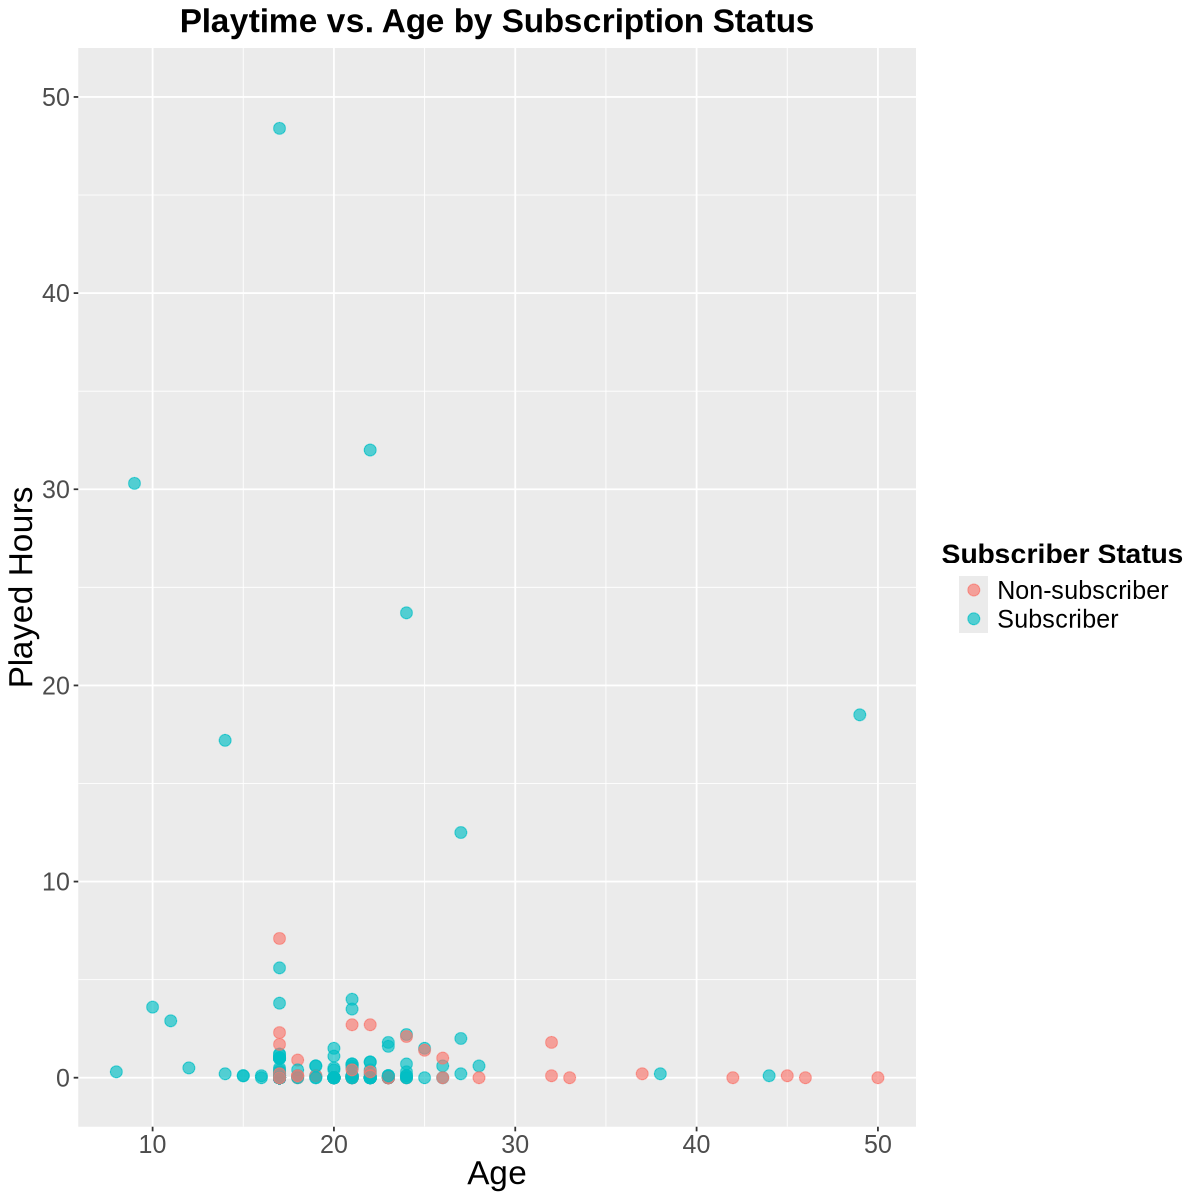

In [6]:
# Set the plot dimensions for clearer visualization
options(repr.plot.width = 10, repr.plot.height = 10)

# Create a scatter plot of Played Hours vs Age, colored by Subscriber Status
ggplot(players, aes(x = age, y = played_hours, color = factor(subscriber_status))) +
  geom_point(alpha = 0.65, size = 3) +                                  # Add semi-transparent points to show density
  labs(
    title = "Playtime vs. Age by Subscription Status",                
    x = "Age",                                                         
    y = "Played Hours",                                               
    color = "Subscriber Status"                                       
  ) +
  coord_cartesian(ylim = c(0, 50)) +                                   # Limit y-axis to focus on typical playtime
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20), # Center and bold the title
    axis.text.x = element_text(size = 15),                            # Increase font size for x-axis tick labels
    axis.text.y = element_text(size = 15),                            # Increase font size for y-axis tick labels
    axis.title.x = element_text(size = 20),                           # Increase font size for x-axis title
    axis.title.y = element_text(size = 20),                           # Increase font size for y-axis title
    legend.title = element_text(face = "bold", size = 17, hjust = 0.5), # Make Legend title bold
    legend.text = element_text(size = 15)                             # Make Legend text larger
  )

In [7]:
# Create a tibble of k values to try (from 1 to 40)
# These represent the different numbers of neighbors we want to evaluate for KNN
k_vals <- tibble(neighbors = seq(from = 1, to = 40, by = 1))

# Define a function to tune KNN for a given random seed
# We run the entire KNN tuning process for one specific seed
tune_knn_for_seed <- function(seed) {
  # Set the random seed for reproducibility
  set.seed(seed)
  
  # Split the data into training and testing sets (75% train, 25% test)
  # Stratified by subscription status to maintain class balance
  players_split <- initial_split(baked_data, prop = 0.75, strata = subscriber_status)
  training_set <- training(players_split)
  testing_set <- testing(players_split)

  # Define a preprocessing recipe (but don't prep yet)
  # We'll scale and center the predictors so KNN isn't biased by their magnitude
  player_recipe_training <- recipe(subscriber_status ~ played_hours + age, data = training_set) |>
    step_scale(all_predictors()) |>
    step_center(all_predictors())
  
  # Define a tunable KNN model specification
  # We set `neighbors = tune()` so that we can try multiple k-values during tuning
  knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
    set_engine("kknn") |>
    set_mode("classification")
  
  # Create 10-fold cross-validation folds
  # Again, stratify by class to keep class balance in each fold
  cv_folds <- vfold_cv(training_set, v = 10, strata = subscriber_status)
  
  # Set up the modeling workflow
  # Add recipe and model to a workflow, then tune across the k values using the CV folds
  tuned <- workflow() |>
    add_recipe(player_recipe_training) |>
    add_model(knn_spec) |>
    tune_grid(
      resamples = cv_folds,  # Use our 10-fold CV
      grid = k_vals          # Try all values of k from 1 to 40
    ) |>
    collect_metrics() |>     # Get accuracy metrics for each k
    filter(.metric == "accuracy") |>  # Only keep accuracy (ignore other metrics)
    mutate(seed = seed)      # Tag results with the seed used
  
  return(tuned)  # Return the accuracy results for all k values for this seed
}

# Step 6: Repeat the tuning process across multiple random seeds
# This helps ensure our tuning isn't biased by one random split of the data
seeds <- 1:10
all_knn_results <- map_dfr(seeds, tune_knn_for_seed)  # Combine results from all seeds


In [8]:
# Step 1: Compute the average accuracy for each k value across all seeds

mean_accuracies <- all_knn_results |> 
  group_by(neighbors) |>                         # Group results by number of neighbors (k)
  summarise(mean_accuracy = mean(mean),          # Compute the average accuracy for each k
            .groups = "drop")                    # Drop the grouping structure from the output

# View the average accuracies for each k
mean_accuracies

# Step 2: Find the best-performing k values based on average accuracy

best_k <- mean_accuracies |> 
  arrange(desc(mean_accuracy)) |>  # Sort k values in descending order of accuracy
  slice(1:5) |>                    # Select the top 5 highest-performing k values
  pull(neighbors)                 # Extract just the k values (not the accuracy)

# View the best k values
best_k


neighbors,mean_accuracy
<dbl>,<dbl>
1,0.6725909
2,0.6694091
3,0.6681364
⋮,⋮
38,0.5806818
39,0.5760909
40,0.5710455


[1] 1 4 2 3 5

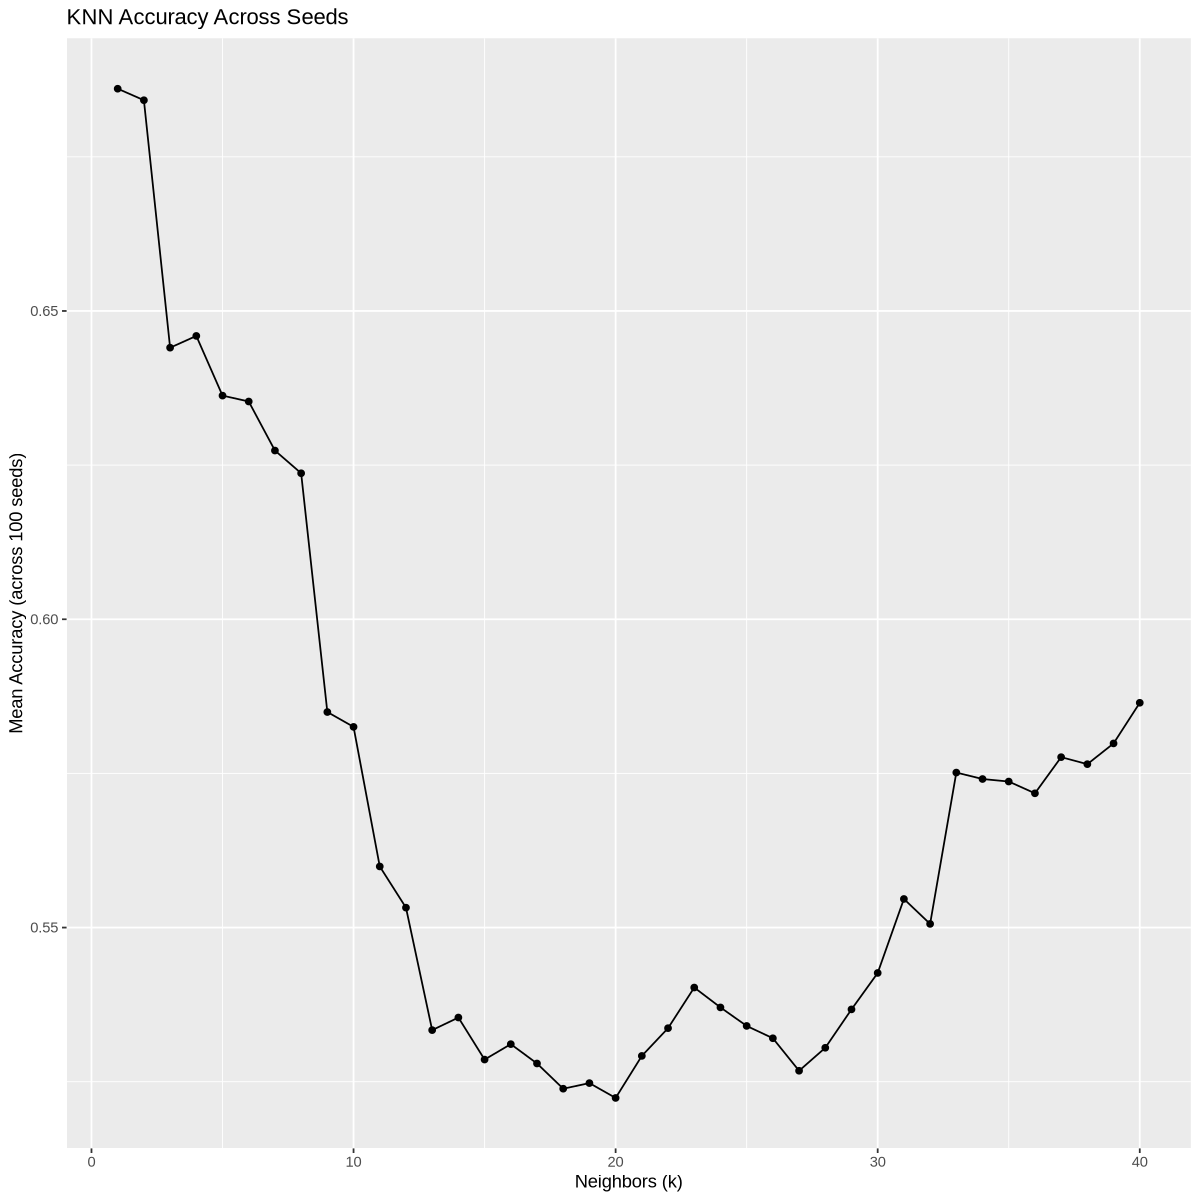

In [46]:
# Plot the average KNN accuracy across different values of k (number of neighbors)
ggplot(mean_accuracies, aes(x = neighbors, y = mean_accuracy)) +
  geom_point() +
  geom_line() +
  labs(x = "Neighbors (k)", y = "Mean Accuracy (across 100 seeds)",
       title = "KNN Accuracy Across Seeds") 
# We will select the *odd-numbered* k that has the highest accuracy because:
# → In binary classification, using an odd k helps avoid ties in majority voting.
# → This ensures the model always makes a decision without randomly breaking ties.
# → If the top-performing k is even, we typically choose the closest odd number with comparable accuracy.

In [9]:
# NOTE:
# We're redefining these objects in the global environment because earlier they were created inside a function.
# In R, anything defined inside a function is local to that function and disappears afterward. By creating them again here, we can use them in later code chunks (e.g., training the final model, plotting, etc.)

# Step 1: Split the preprocessed dataset (baked_data) into training and testing sets
# Use stratified sampling based on `subscriber_status` to preserve class proportions
players_split <- initial_split(baked_data, prop = 0.75, strata = subscriber_status)
training_set <- training(players_split)   # 75% for training
testing_set <- testing(players_split)     # 25% for testing

# Step 2: Define a new recipe on the training set
# We apply the same preprocessing steps (centering and scaling predictors)
player_recipe_training <- recipe(subscriber_status ~ played_hours + age, data = training_set) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

# Step 3: Check class balance in the training set
training_set |>
  count(subscriber_status) |>          
  mutate(prop = n / sum(n))            

# Step 4: Check class balance in the testing set
testing_set |>
  count(subscriber_status) |>
  mutate(prop = n / sum(n))           

# These checks ensure that stratified splitting worked correctly, and both sets maintain roughly equal representation of each class.


subscriber_status,n,prop
<fct>,<int>,<dbl>
Non-subscriber,106,0.5
Subscriber,106,0.5


subscriber_status,n,prop
<fct>,<int>,<dbl>
Non-subscriber,36,0.5
Subscriber,36,0.5


In [11]:
# Define the final KNN model specification
knn_spec <- nearest_neighbor(
    weight_func = "rectangular",   # Use uniform (non-weighted) voting among neighbors
    neighbors = 3                  # Use the best odd k value found during tuning
  ) |>
  set_engine("kknn") |>            # Specify the engine to use for KNN (kknn package)
  set_mode("classification")       # Set mode to classification (since we're predicting categories)

# Create a modeling workflow and train (fit) the final model
knn_fit <- workflow() |>
  add_recipe(player_recipe_training) |>   # Add the preprocessing recipe (scaling & centering)
  add_model(knn_spec) |>                  # Add the finalized KNN model spec
  fit(data = training_set)                # Fit the model to the training data

# View the trained model/workflow
knn_fit


══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(3,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.259434
Best kernel: rectangular
Best k: 3

In [12]:
# Make predictions on the testing set using the final trained KNN model
# The predictions will be in a column named `.pred_class`
players_test_predictions <- predict(knn_fit, testing_set) |>
  bind_cols(testing_set)   # Combine predictions with the original test data

# Calculate overall accuracy of the predictions
players_test_predictions |>
  metrics(truth = subscriber_status, estimate = .pred_class) |>  # Compare predicted vs actual
  filter(.metric == "accuracy")                                  # Keep only the accuracy metric

# Calculate precision
# Precision tells us: Of all predicted "Non-subscribers", how many were actually correct?
# `event_level = "first"` tells yardstick to treat the *first factor level* ("Non-subscriber") as the positive class
players_test_predictions |>
  precision(truth = subscriber_status, estimate = .pred_class, event_level = "first")

# Calculate recall
# Recall tells us: Of all *actual* "Non-subscribers", how many did we correctly predict?
players_test_predictions |>
  recall(truth = subscriber_status, estimate = .pred_class, event_level = "first")

# Generate a confusion matrix
# This shows a table of predicted vs actual classes, letting you see where the model got things right or wrong
confusion <- players_test_predictions |>
  conf_mat(truth = subscriber_status, estimate = .pred_class)

# View the confusion matrix
confusion


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.5972222


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.5614035


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.8888889


                Truth
Prediction       Non-subscriber Subscriber
  Non-subscriber             32         25
  Subscriber                  4         11

In [70]:
# Prep the recipe on the training data
# We create a new version (player_recipe_training2) and run `prep()` on it so that we can later use it with `bake()` to preprocess new data
player_recipe_training2 <- recipe(subscriber_status ~ played_hours + age, data = training_set) |> 
  step_scale(all_predictors()) |>      # Standardize predictors: scale to unit variance
  step_center(all_predictors()) |>     # Standardize predictors: center to mean = 0
  prep()                               # Preps the recipe (estimates means/SDs from training data)

# Define a new observation (e.g., a new player)
# This observation is outside your original dataset
new_observation <- tibble(played_hours = 5.0, age = 20)

# Preprocess the new observation using the prepped recipe
# This applies the same centering and scaling as used during training
new_baked <- bake(player_recipe_training2, new_data = new_observation)

# Predict the class label using the trained KNN model
predict(knn_fit, new_data = new_baked)


.pred_class
<fct>
Subscriber


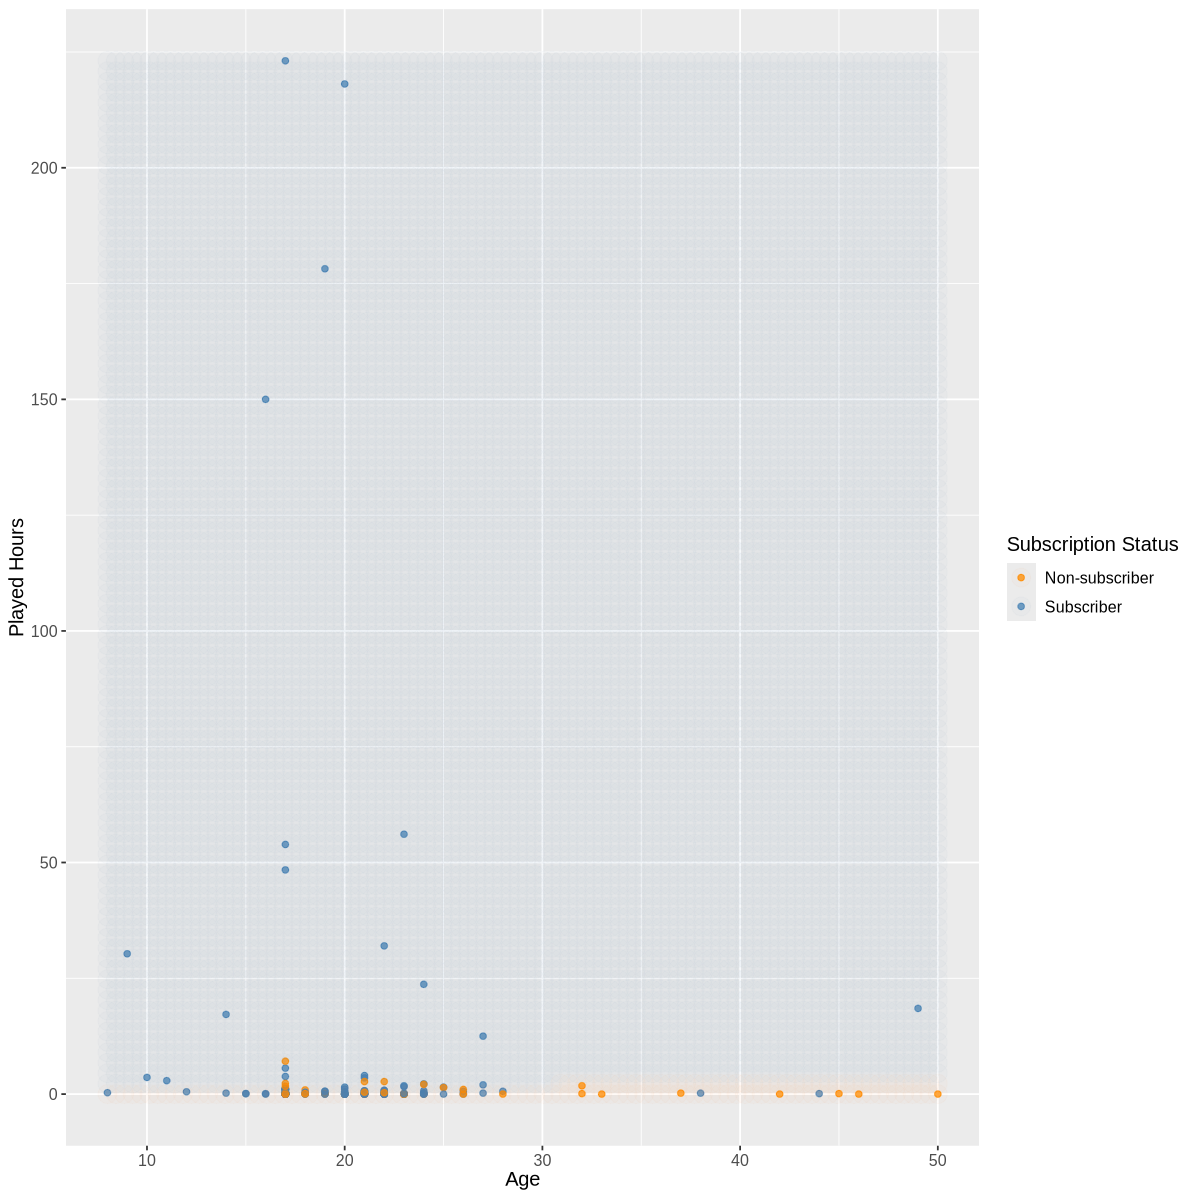

In [78]:
# Generate a grid of values covering the entire feature space, this grid will help us visualize what the model would predict at every age/played_hours combination

age_grid <- seq(min(players$age),               # Range of ages in the dataset
                max(players$age),
                length.out = 100)               # 100 evenly spaced points

hours_grid <- seq(min(players$played_hours),    # Range of played hours
                  max(players$played_hours),
                  length.out = 100)

ph_grid <- expand.grid(                         # Create a grid of all (age, played_hours) combinations
  age = age_grid,
  played_hours = hours_grid
) |>
  as_tibble()                                   # Convert to tibble for tidyverse compatibility

# Preprocess the grid using the prepped recipe, this ensures the grid is scaled/centered the same way as the training data
ph_grid_baked <- bake(player_recipe_training2, new_data = ph_grid)

# Predict the class for each grid point using the trained KNN model
knn_grid_preds <- predict(knn_fit, new_data = ph_grid_baked)

# Combine the predictions with the original grid values, this gives us a table of (age, played_hours, predicted_class)
prediction_table <- bind_cols(knn_grid_preds, ph_grid) |>
  rename(Class = .pred_class)

# Plot the decision regions and overlay the actual data
wkflw_plot <- ggplot() +
  geom_point(
    data = players,
    mapping = aes(x = age, y = played_hours, color = subscriber_status),
    alpha = 0.75
  ) +
  geom_point(
    data = prediction_table,
    mapping = aes(x = age, y = played_hours, color = Class),
    alpha = 0.02,
    size = 5
  ) +
  labs(
    color = "Subscription Status",
    x = "Age",
    y = "Played Hours"
  ) +
  scale_color_manual(values = c("Non-subscriber" = "darkorange",
                                "Subscriber" = "steelblue")) +
  theme(text = element_text(size = 12))

# Display the final plot
wkflw_plot




## Discussion

## References